In [2]:
from datetime import datetime, timezone, timedelta
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
#import glob
#import netCDF4 as nc
import xarray as xr
# import grib2io

#import cfgrib
import urllib
#import pygrib

sys.path.append('../sdpm_py_util')
sys.path.append('../web_util')

#import init_funs as initfuns
#import ocn_functions as ocnfuns
import plotting_functions as pltfuns
#import atm_functions as atmfuns
#import hind_functions as hindfuns
import grid_functions as grdfuns
#import web_functions as webfuns
from get_PFM_info import get_PFM_info

#import pickle
#import os
import subprocess

/project/vboatwright/PFM_dir/PFM_for_rockfish/sdpm_py_util/plotting_functions.py:2106: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
  all_observed_v2 = [t if t is not '' else '-9999' for t in all_observed_v]
/project/vboatwright/PFM_dir/PFM_for_rockfish/sdpm_py_util/plotting_functions.py:2107: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
  all_predicted_v2 = [t if t is not '' else '-9999' for t in all_predicted_v]


In [3]:
# plot of .his files

# LV3_ocean_his_202410110000.nc

levels = [1,2,3]
for lv in levels: 
    lv_name = f'LV{lv}_ocean_his_202410110000.nc'
    print(lv_name)


LV1_ocean_his_202410110000.nc
LV2_ocean_his_202410110000.nc
LV3_ocean_his_202410110000.nc


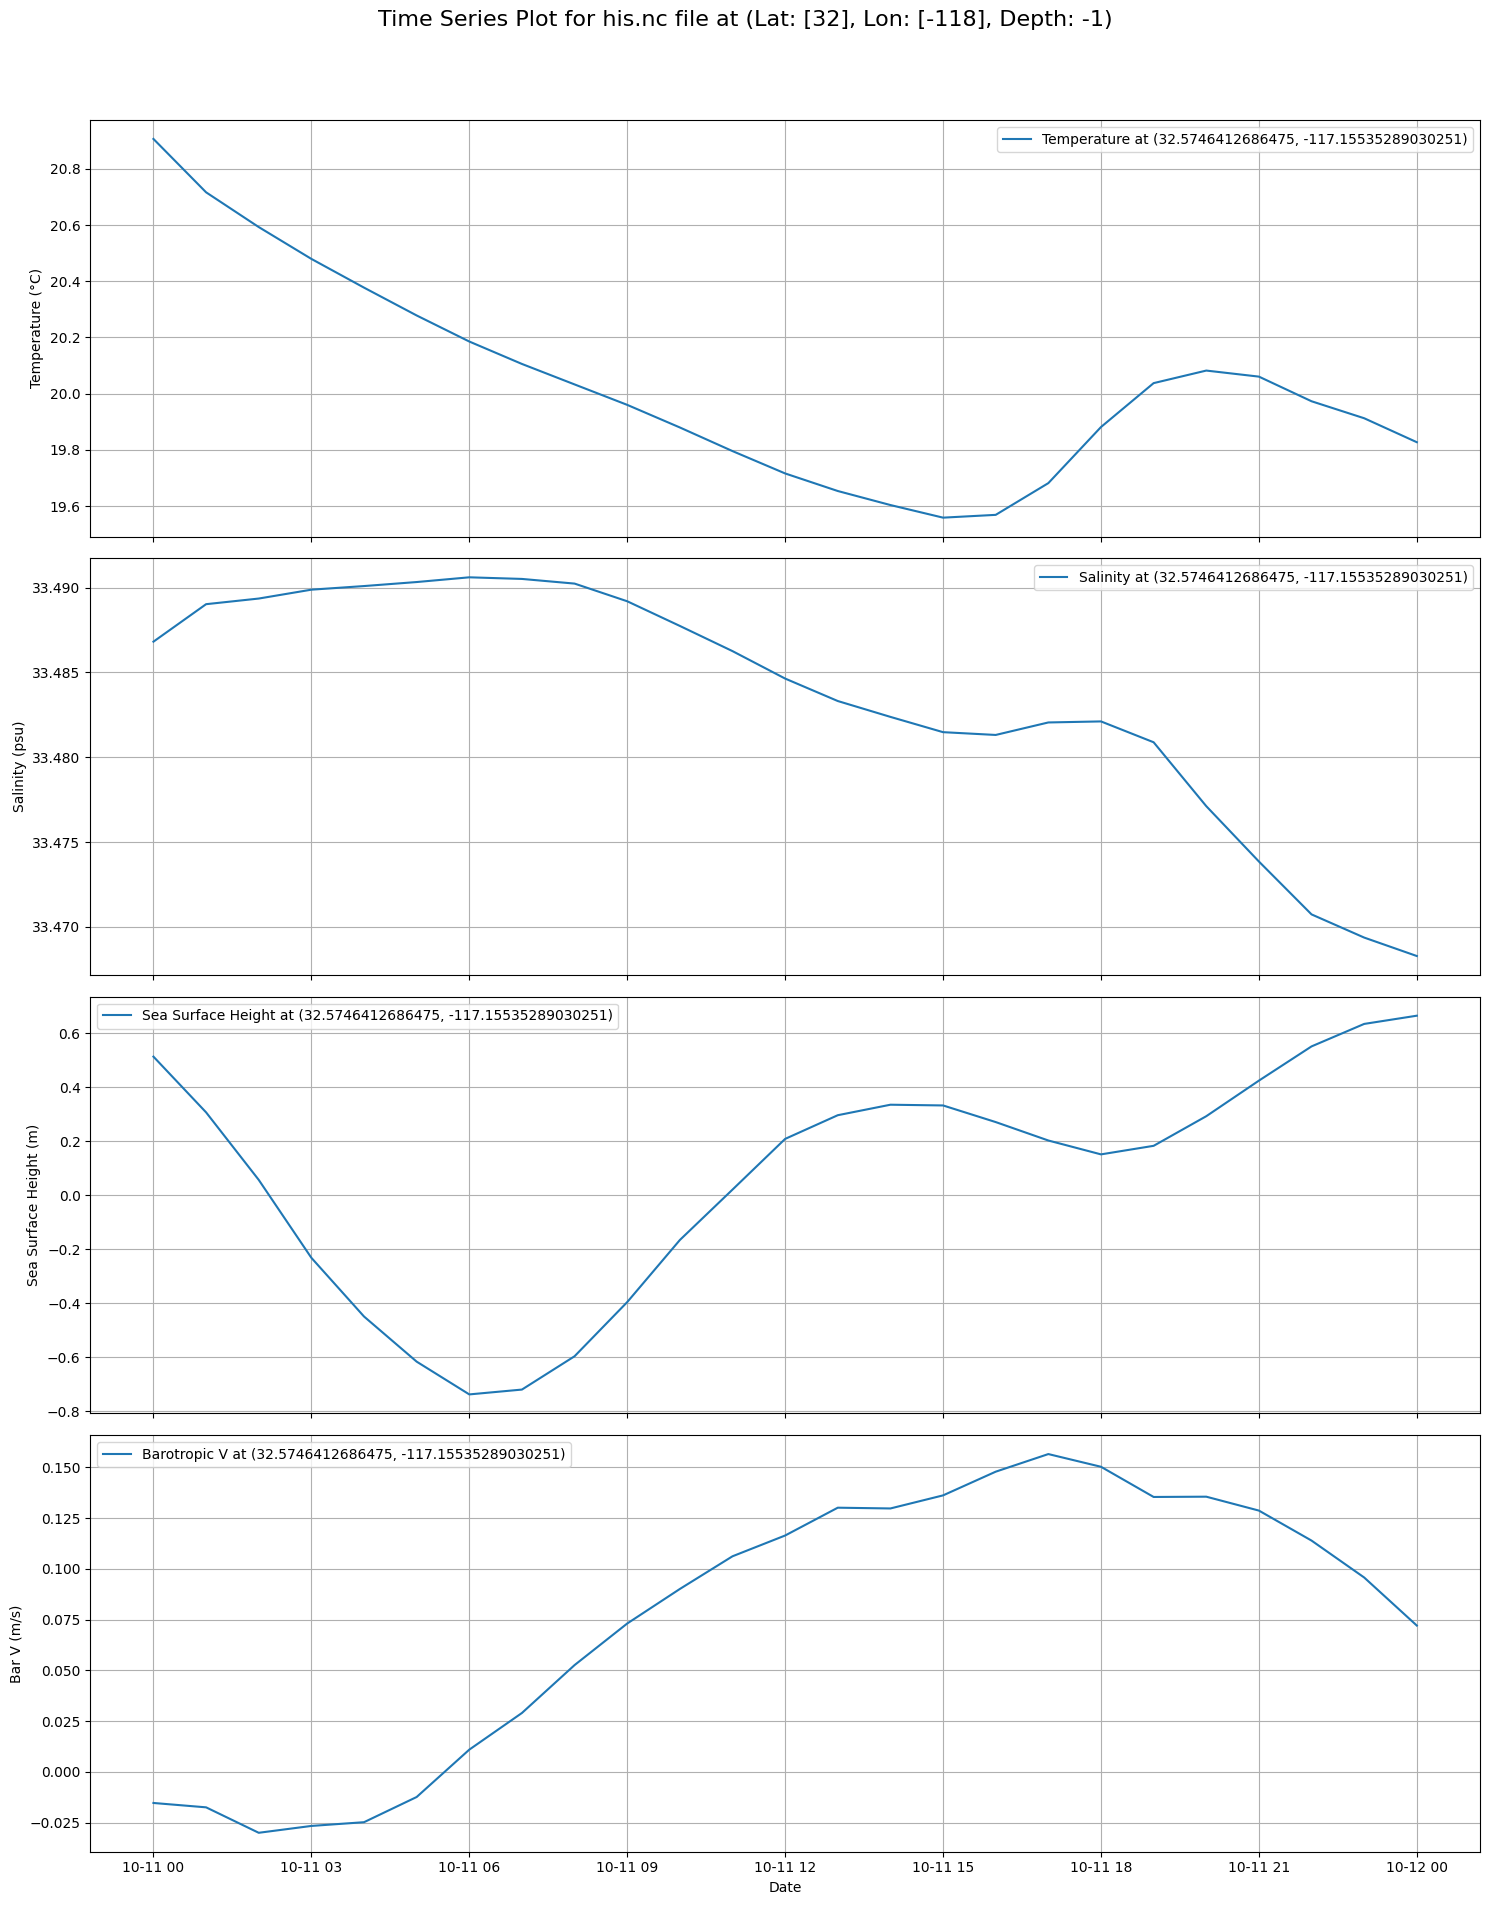

In [8]:
his_filepath = '/project/vboatwright/PFM_dir/simulations/LV3/His/LV3_ocean_his_202410110000.nc'
#fngr = '/project/vboatwright/PFM_dir/simulations/grids/GRID_SDTJRE_LV3_rx020.nc'
fngr = '/project/vboatwright/PFM_dir/simulations/grids/GRID_LV3_LPL_rx020.nc'
import grid_functions as grdfuns
RMG = grdfuns.roms_grid_to_dict(fngr)
lat = [32]  # latitude 
lon = [-118]  # longitude

pltfuns.plot_his_time_series(his_filepath, RMG, lat, lon, depth_level=-1)


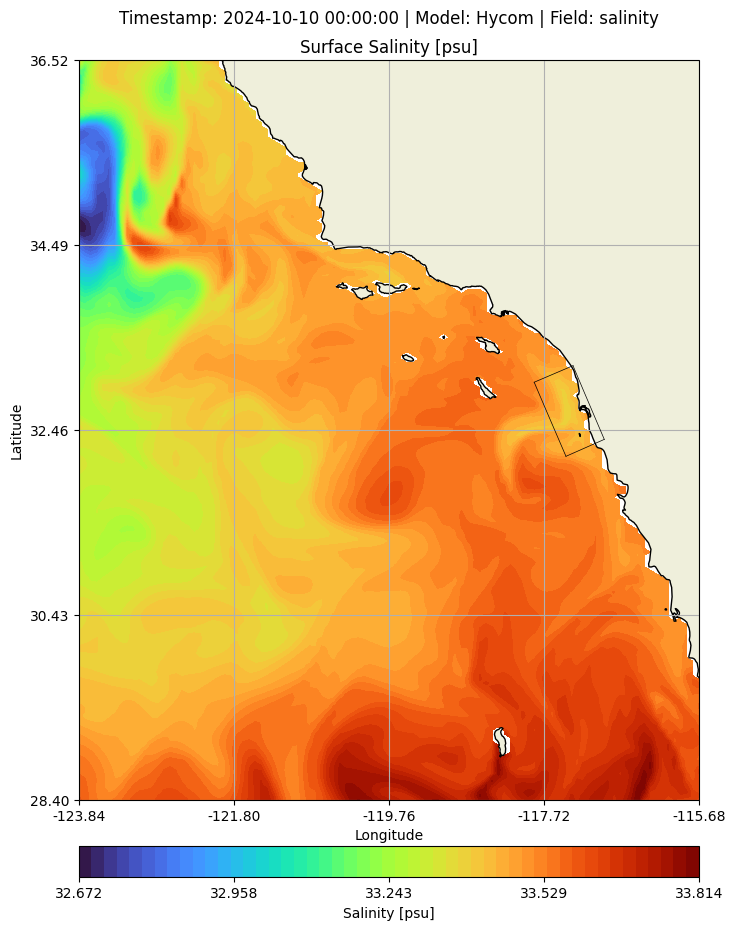

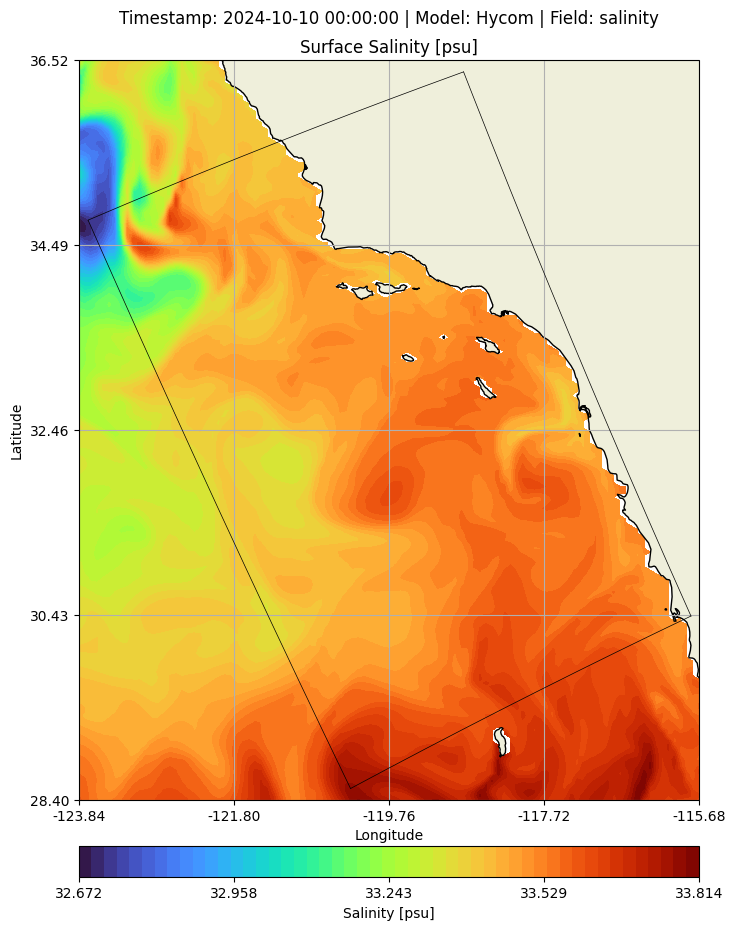

In [18]:
his_filepath = '/project/vboatwright/PFM_dir/simulations/LV3/His/LV3_ocean_his_202410110000.nc'
#fngr = '/project/vboatwright/PFM_dir/simulations/grids/GRID_SDTJRE_LV3_rx020.nc'
fngr = '/project/vboatwright/PFM_dir/simulations/grids/GRID_LV3_LPL_rx020.nc'
import grid_functions as grdfuns
RMG = grdfuns.roms_grid_to_dict(fngr)
lat = [32]  # latitude 
lon = [-118]  # longitude

# this is for HYCOM data 
filepath = '/project/vboatwright/pfm_hindcast_data/model_forcing/hycom_nc/hycom_hind_2024101000_00_s3z.nc'
pltfuns.plot_ocn_fields_from_nc(filepath, RMG, fields_to_plot=['salinity'], show=False)

# now also show with LV1
fngr = '/project/vboatwright/PFM_dir/simulations/grids/GRID_SDTJRE_LV1_rx020_hmask.nc'
RMG = grdfuns.roms_grid_to_dict(fngr)
lat = [32]  # latitude 
lon = [-118]  # longitude
pltfuns.plot_ocn_fields_from_nc(filepath, RMG, fields_to_plot=['salinity'], show=False)


In [13]:
import netCDF4 as nc 
ds = nc.Dataset(his_filepath)
ds

<class 'netCDF4.Dataset'>
root group (NETCDF3_64BIT_OFFSET data model, file format NETCDF3):
    file: /home/vboatwright/boat_roms/PFM_dir/simulations/LV3/His/LV3_ocean_his_202410110000.nc
    format: netCDF-3 64bit offset file
    Conventions: CF-1.4, SGRID-0.3
    type: ROMS history file
    title: LV3 Forecast ROMS
    var_info: /home/vboatwright/boat_roms/roms/ROMS/External/varinfo.yaml
    rst_file: /home/vboatwright/boat_roms/PFM_dir/simulations/restart_data/LV3_ocean_rst_202410110000_202410120000.nc
    his_file: /home/vboatwright/boat_roms/PFM_dir/simulations/LV3/His/LV3_ocean_his_202410110000.nc
    grd_file: /home/vboatwright/boat_roms/PFM_dir/simulations/grids/GRID_LV3_LPL_rx020.nc
    ini_file: /home/vboatwright/boat_roms/PFM_dir/simulations/LV3/Forc/LV3_OCEAN_IC.nc
    frc_file_01: /home/vboatwright/boat_roms/PFM_dir/simulations/LV3/Forc/LV3_ATM_FORCING.nc
    bry_file_01: /home/vboatwright/boat_roms/PFM_dir/simulations/LV3/Forc/LV3_OCEAN_BC.nc
    script_file: LV3_forecas

In [ ]:
['temp', 'salt', 'ubar', 'vbar', ]

In [14]:
print(f'time-stepping: {ds['dt']}')
print(f'fast time-stepping: {ds['ndtfast']}')

time-stepping: <class 'netCDF4.Variable'>
float64 dt()
    long_name: size of long time-steps
    units: second
unlimited dimensions: 
current shape = ()
filling on, default _FillValue of 9.969209968386869e+36 used
fast time-stepping: <class 'netCDF4.Variable'>
int32 ndtfast()
    long_name: number of short time-steps
unlimited dimensions: 
current shape = ()
filling on, default _FillValue of -2147483647 used


In [ ]:

def plot_ocn_fields_from_nc(file_path, RMG, fields_to_plot=None, show=False):
    """
    Plot specified fields from a NetCDF dataset and save them as PNG files.
    
    Parameters:
    file_path (str): The path to the NetCDF file.
    fields_to_plot (list or str): The fields to plot. If None, plot all fields.
    """
    # Load the NetCDF file
    dataset = nc.Dataset(file_path)

    # Extract the common variables
    lon = dataset.variables['lon_rho'][:]
    lat = dataset.variables['lat_rho'][:]
    lon = np.where(lon > 180, lon - 360, lon) # Remove this line when using the dictionary as Matt does the longitude conversion there.
    time = dataset.variables['ocean_time'][0]  # Only considering the first time step for simplicity
    start_time = nc.num2date(time, units=dataset.variables['time'].units)

    if fields_to_plot is None:
        fields_to_plot = ['velocity', 'surf_el', 'water_temp', 'salinity']
    else:
        fields_to_plot = [fields_to_plot] if isinstance(fields_to_plot, str) else fields_to_plot

    for field in fields_to_plot:
        fig, ax = plt.subplots(figsize=(8, 12), subplot_kw={'projection': ccrs.PlateCarree()})
        cmap = plt.get_cmap('turbo')
        plt.set_cmap(cmap)

        if field == 'velocity':
            u = dataset.variables['water_u'][0, 0, :, :]  # surface layer
            v = dataset.variables['water_v'][0, 0, :, :]  # surface layer
            magnitude = np.sqrt(u**2 + v**2)
            plevs = np.linspace(np.nanmin(magnitude), np.nanmax(magnitude), 50)
            cset = ax.contourf(lon, lat, magnitude, plevs, cmap=cmap, transform=ccrs.PlateCarree())
            ax.quiver(lon[::5], lat[::5], u[::5, ::5], v[::5, ::5], transform=ccrs.PlateCarree())
            cbar = fig.colorbar(cset, ax=ax, orientation='horizontal', pad=0.05)
            cbar.set_label('Velocity Magnitude [m/s]')
            cbar.set_ticks(np.linspace(np.nanmin(magnitude), np.nanmax(magnitude), 5))
            ax.set_title('Surface Velocity [m/s]')
        
        elif field == 'surf_el':
            surf_el = dataset.variables['surf_el'][0, :, :]
            plevs = np.linspace(np.nanmin(surf_el), np.nanmax(surf_el), 50)
            cset = ax.contourf(lon, lat, surf_el, plevs, cmap=cmap, transform=ccrs.PlateCarree())
            cbar = fig.colorbar(cset, ax=ax, orientation='horizontal', pad=0.05)
            cbar.set_label('Surface Elevation [m]')
            cbar.set_ticks(np.linspace(np.nanmin(surf_el), np.nanmax(surf_el), 5))
            ax.set_title('Surface Elevation [m]')
        
        elif field == 'water_temp':
            water_temp = dataset.variables['water_temp'][0, 0, :, :]
            plevs = np.linspace(np.nanmin(water_temp), np.nanmax(water_temp), 50)
            cset = ax.contourf(lon, lat, water_temp, plevs, cmap=cmap, transform=ccrs.PlateCarree())
            cbar = fig.colorbar(cset, ax=ax, orientation='horizontal', pad=0.05)
            cbar.set_label('Surface Temperature [°C]')
            cbar.set_ticks(np.linspace(np.nanmin(water_temp), np.nanmax(water_temp), 5))
            ax.set_title('Surface Temperature [°C]')
        
        elif field == 'salinity':
            salinity = dataset.variables['salinity'][0, 0, :, :]
            plevs = np.linspace(np.nanmin(salinity), np.nanmax(salinity), 50)
            cset = ax.contourf(lon, lat, salinity, plevs, cmap=cmap, transform=ccrs.PlateCarree())
            cbar = fig.colorbar(cset, ax=ax, orientation='horizontal', pad=0.05)
            cbar.set_ticks(np.linspace(np.nanmin(salinity), np.nanmax(salinity), 5))
            cbar.set_label('Salinity [psu]')
            ax.set_title('Surface Salinity [psu]')
        
        # Add coastlines and gridlines and ROMS box
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        ax.add_feature(cfeature.LAND, zorder=1, edgecolor='black')
        ax.grid(True)
        plot_roms_box(ax, RMG)
        ax.set_aspect('auto')
        ax.set_xticks(np.round(np.linspace(np.min(lon), np.max(lon), num=5), 2))
        ax.set_yticks(np.round(np.linspace(np.min(lat), np.max(lat), num=5), 2))
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))
        
        # Set the title and labels
        annotation = f'Timestamp: {start_time.strftime("%Y-%m-%d %H:%M:%S")} | Model: Hycom | Field: {field}'
        ax.text(0.5, 1.05, annotation, transform=ax.transAxes, ha='center', fontsize=12)
        
        plt.show()
        plt.close()
    
    # Close the dataset
    dataset.close()


In [22]:
import cmocean 

In [28]:
ds

<class 'netCDF4.Dataset'>
root group (NETCDF3_64BIT_OFFSET data model, file format NETCDF3):
    file: /home/vboatwright/boat_roms/PFM_dir/simulations/LV3/His/LV3_ocean_his_202410110000.nc
    format: netCDF-3 64bit offset file
    Conventions: CF-1.4, SGRID-0.3
    type: ROMS history file
    title: LV3 Forecast ROMS
    var_info: /home/vboatwright/boat_roms/roms/ROMS/External/varinfo.yaml
    rst_file: /home/vboatwright/boat_roms/PFM_dir/simulations/restart_data/LV3_ocean_rst_202410110000_202410120000.nc
    his_file: /home/vboatwright/boat_roms/PFM_dir/simulations/LV3/His/LV3_ocean_his_202410110000.nc
    grd_file: /home/vboatwright/boat_roms/PFM_dir/simulations/grids/GRID_LV3_LPL_rx020.nc
    ini_file: /home/vboatwright/boat_roms/PFM_dir/simulations/LV3/Forc/LV3_OCEAN_IC.nc
    frc_file_01: /home/vboatwright/boat_roms/PFM_dir/simulations/LV3/Forc/LV3_ATM_FORCING.nc
    bry_file_01: /home/vboatwright/boat_roms/PFM_dir/simulations/LV3/Forc/LV3_OCEAN_BC.nc
    script_file: LV3_forecas

In [38]:
Ix[:,:

251

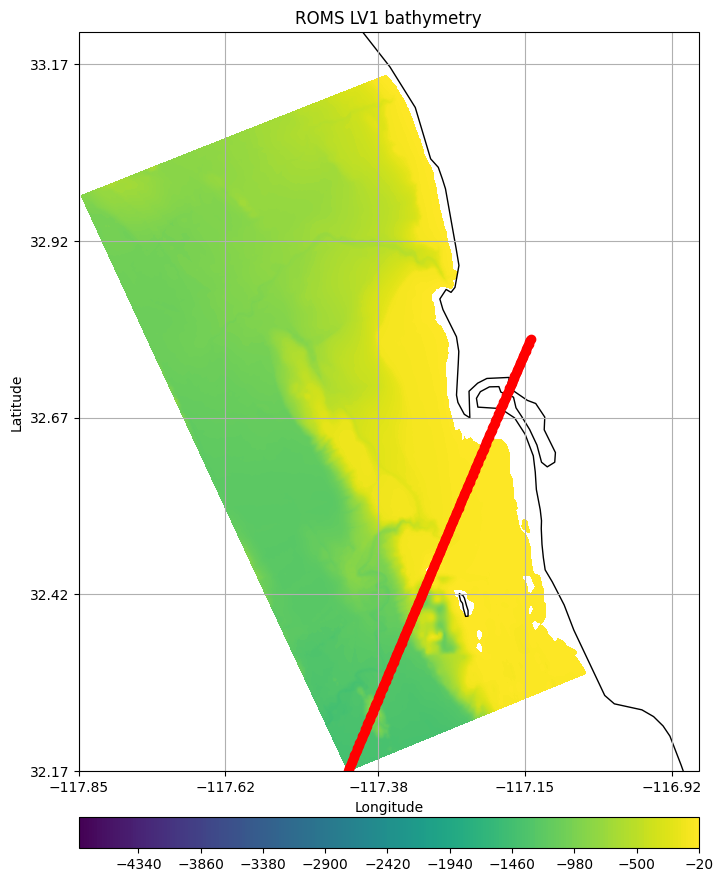

In [40]:
# xi_rho(251), xi_u(250), xi_v(251), xi_psi(250), eta_rho(476), eta_u(476), eta_v(475), eta_psi(475), N(40), s_rho(40), s_w(41), tracer(2), boundary(4), ocean_time(25)
fn = his_filepath 
Ix = 251; Iy = 476
Ix = np.arange(len(ds['lon_rho'][:,:].data[0,:]))
Iy = np.arange(len(ds['lon_rho'][:,:].data[:,0]))

sv_fig = '1' 

pltfuns.plot_roms_LV1_bathy_and_locs(fn,Ix,Iy,sv_fig)

In [66]:
len(ds['ocean_time'][:].data)

25

In [67]:
his_filepath = '/project/vboatwright/PFM_dir/simulations/LV3/His/LV3_ocean_his_202410110000.nc'
#fngr = '/project/vboatwright/PFM_dir/simulations/grids/GRID_SDTJRE_LV3_rx020.nc'
fngr = '/project/vboatwright/PFM_dir/simulations/grids/GRID_LV3_LPL_rx020.nc'
RMG = grdfuns.roms_grid_to_dict(fngr)
lat = [32]  # latitude 
lon = [-118]  # longitude

fn = his_filepath 
It = np.arange(len(ds['ocean_time'][:].data)); 
Iz = np.arange(len(ds['s_rho'][:].data))
It = 20; Iz = 39

sv_fig = '1' 
lvl ='LV3' 
cmn = 0
cmx = 30; 

driver_path = '/project/vboatwright/PFM_dir/PFM_for_rockfish/driver/'
pyutil_path = '/project/vboatwright/PFM_dir/PFM_for_rockfish/sdpm_py_util/'
simulation_path = '/project/vboatwright/PFM_dir/simulations/'
pkl_fnm = simulation_path+'phm_modinfo_testing.pkl'


plot_his_temps_wuv(fn,It,Iz,sv_fig,lvl,cmn,cmx,pkl_fnm)


LV3
using lv3 grid file


ValueError: operands could not be broadcast together with shapes (475,250) (412,250) 

In [49]:
def plot_his_temps_wuv(fn,It,Iz,sv_fig,lvl,cmn,cmx,pkl_fnm):
    import init_funs_forecast as initfuns

    print(lvl)

    cmn = float(cmn) # these are the colorbar limits
    cmx = float(cmx)

    cmn = np.floor(10*cmn) / 10
    cmx = np.ceil(10*cmx) / 10

    if lvl == 'LV4':
        dc = cmx - cmn
        cmn2 = cmn + .25*dc
        cmx = cmn + .95*dc
        cmn = cmn2
        cmn = np.floor(10*cmn) / 10
        cmx = np.ceil(10*cmx) / 10

    cmn = cmn - .1
    cmx = cmx + .1

    PFM=initfuns.get_model_info( pkl_fnm )
    if lvl == 'LV1':
        RMG = grdfuns.roms_grid_to_dict(PFM['lv1_grid_file'])
        res = '110m'
        res2 = 'i'
    elif lvl == 'LV2':
        RMG = grdfuns.roms_grid_to_dict(PFM['lv2_grid_file'])
        res = '50m'
        res2 = 'h'
    elif lvl == 'LV3':
        print('using lv3 grid file')
        RMG = grdfuns.roms_grid_to_dict(PFM['lv3_grid_file'])
        res = '10m'
        res2 = 'f'
    elif lvl == 'LV4':
        RMG = grdfuns.roms_grid_to_dict(PFM['lv4_grid_file'])
        res = '10m'
        res2 = 'f'

    his_ds = nc.Dataset(fn)
    #lt = his_ds.variables['lat_rho'][:]
    lt = RMG['lat_rho'][:]
    #ln = his_ds.variables['lon_rho'][:]
    ln = RMG['lon_rho'][:]


    #print(his_ds.variables.keys())

    if lvl == 'LV4':
        msk = his_ds.variables['wetdry_mask_rho'][It,:,:]
        msk = np.squeeze(msk)
    else:
        msk = his_ds.variables['mask_rho'][:,:]

    It = int(It)
    Iz = int(Iz)
    temp = his_ds.variables['temp'][It,Iz,:,:]
    temp = temp.data
    temp == np.squeeze(temp)
    
    temp[msk==0] = np.nan 

    #tempall = his_ds.variables['temp'][:,Iz,:,:]

    urm = np.squeeze( his_ds.variables['u'][It,Iz,:,:] )
    vrm = np.squeeze( his_ds.variables['v'][It,Iz,:,:] )
    urm2 = np.squeeze( .5 * (urm[0:-1,:]+urm[1:,:]) ) # now on rho points, but not 0 or -1
    vrm2 = np.squeeze( .5 * (vrm[:,0:-1]+vrm[:,1:]) )
    ang = RMG['angle'] # on rho points
    ang2 = np.squeeze( .5* (ang[0:-1,0:-1] + ang[1:,1:]  ))
    u = urm2 * np.cos(ang2) - vrm2 * np.sin(ang2)
    v = vrm2 * np.cos(ang2) + urm2 * np.sin(ang2)

    #print(np.shape(u))
    #print(np.shape(v))

    fig, ax = plt.subplots(figsize=(8, 12), subplot_kw={'projection': ccrs.PlateCarree()})
    plevs = np.arange(cmn,cmx,.05)
    cmap = plt.get_cmap('turbo')
    cset = ax.contourf(ln, lt, temp, plevs, cmap=cmap, extend="both", vmin=cmn, vmax=cmx, transform=ccrs.PlateCarree())        
    plt.set_cmap(cmap)
    cbar = fig.colorbar(cset, ax=ax, orientation='horizontal', pad = 0.05)

    ln2 = .5* (ln[0:-1,0:-1]+ln[1:,1:])
    lt2 = .5* (lt[0:-1,0:-1]+lt[1:,1:])

    if lvl == 'LV1' or lvl =='LV2' or lvl == 'LV3':
        ax.quiver(ln2[0::8,0::8], lt2[0::8,0::8], u[0::8,0::8], v[0::8,0::8], transform=ccrs.PlateCarree())

    times = his_ds.variables['ocean_time']
    times2 = num2date(times[:], times.units)
    times2 = np.array([datetime(year=date.year, month=date.month, day=date.day, 
                              hour=date.hour, minute=date.minute, second=date.second) for date in times2])

    start_time = times2[0]
    forecast_hours = It
    tzone = datetime.now().astimezone().tzinfo
    if str(tzone) == 'PDT':
        toff = -7
    elif str(tzone) == 'PST':
        toff = -8
    tfore = times2[It] + toff * timedelta(hours=1)    
    annotation = (f'{lvl} Surface Temp [C] and currents | Forecast: {start_time.strftime("%Y-%m-%d %H:%M:%S")}\n' 
                   f'Forecast Hour: {forecast_hours:.1f} ({tfore.strftime("%Y-%m-%d %H:%M:%S")} {str(tzone)})')

    ax.text(0.5, 1.05, annotation, transform=ax.transAxes, ha='center', fontsize=12)
    ax.add_feature(cfeature.LAND)
    ax.add_feature(cfeature.BORDERS)
    #coast = cfeature.GSHHSFeature(scale='full')
    #ax.add_feature(cfeature.COASTLINE, resolution=res, linewidth = 1.25)   
    if lvl != 'LV4':
        coast = cfeature.GSHHSFeature(scale=res2)
        ax.add_feature(coast)
    #ax.coastlines(resolution=res)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(True)
    ax.set_aspect(aspect='auto')
    ax.set_xticks(np.round(np.linspace(np.min(ln), np.max(ln), num=5), 2))
    ax.set_yticks(np.round(np.linspace(np.min(lt), np.max(lt), num=5), 2))

    it_str = str(It).zfill(3)

    yyyymmddhh = PFM['sim_time_1'].strftime('%Y%m%d%H')

    if sv_fig == '1':
        if lvl == 'LV1':
            fn_out = PFM['lv1_plot_dir'] + '/his_tempuv_LV1_' + yyyymmddhh + '_' + it_str + 'hr.png'
        elif lvl == 'LV2':            
            fn_out = PFM['lv2_plot_dir'] + '/his_tempuv_LV2_' + yyyymmddhh + '_' + it_str + 'hr.png'
        elif lvl == 'LV3':            
            fn_out = PFM['lv3_plot_dir'] + '/his_tempuv_LV3_' + yyyymmddhh + '_' + it_str + 'hr.png'
        elif lvl == 'LV4':            
            fn_out = PFM['lv4_plot_dir'] + '/his_tempuv_LV4_' + yyyymmddhh + '_' + it_str + 'hr.png'
        
        plt.savefig(fn_out, dpi=300)
    else:
        plt.show()
